# First step of the project
Training Resnet on CIFAR10 dataset (expected accuracy 90%)
https://medium.com/@thatchawin.ler/cifar10-with-resnet-in-pytorch-a86fe18049df

In [1]:
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import random_split, DataLoader
import torchvision
from torchvision import datasets
from torchvision import transforms
import os
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import pandas as pd
import seaborn as sn
import numpy as np
import random
from typing import List, Dict, Tuple
from tqdm.auto import tqdm
import gc
from google.colab import drive

try:
    from torchinfo import summary
except:
    !pip install torchinfo
    from torchinfo import summary

drive.mount('/content/drive')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Używam urządzenia: {device}")

SAVE_DIR = '/content/drive/MyDrive/model_base/third'
os.makedirs(SAVE_DIR, exist_ok=True)
#srednia i odchylenie standardowe wszystkich pikseli ze zbioru cifar, potrzebne do normalizacji
CIFAR_MEAN = [0.4914, 0.4822, 0.4465]
CIFAR_STD = [0.247, 0.243, 0.261]

NUM_WORKERS = os.cpu_count()
BATCH_SIZE = 800

Mounted at /content/drive
Używam urządzenia: cuda


In [2]:
def train_step(model, dataloader, loss_fn, optimizer, scheduler=None, grad_clip=None):
    model.train()
    train_loss, train_acc = 0, 0

    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)
        y_pred = model(X)
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()

        optimizer.zero_grad()
        loss.backward()

        if grad_clip:
            nn.utils.clip_grad_value_(model.parameters(), grad_clip)

        optimizer.step()

        y_pred_class = torch.argmax(y_pred, dim=1)
        train_acc += (y_pred_class == y).sum().item() / len(y)

    train_loss /= len(dataloader)
    train_acc /= len(dataloader)
    if scheduler is not None and isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
        scheduler.step(train_loss)

    return train_loss, train_acc

def test_step(model, dataloader, loss_fn):
    model.eval()
    test_loss, test_acc = 0, 0

    with torch.inference_mode():
        for batch, (X, y) in enumerate(dataloader):
            X, y = X.to(device), y.to(device)
            test_pred_logits = model(X)
            loss = loss_fn(test_pred_logits, y)
            test_loss += loss.item()
            test_pred_labels = torch.argmax(test_pred_logits, dim=1)
            test_acc += (test_pred_labels == y).sum().item() / len(y)

    test_loss /= len(dataloader)
    test_acc /= len(dataloader)
    return test_loss, test_acc

def train(model, train_dataloader, test_dataloader, optimizer, scheduler, grad_clip=None, loss_fn=nn.CrossEntropyLoss(), epochs=10, save_path=None):
    results = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}
    best_val_loss = float('inf')

    for epoch in tqdm(range(epochs)):
        train_loss, train_acc = train_step(model, train_dataloader, loss_fn, optimizer, scheduler, grad_clip)
        if scheduler is not None and not isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
             scheduler.step()

        test_loss, test_acc = test_step(model, test_dataloader, loss_fn)

        print(f"Epoch: {epoch+1} | train_loss: {train_loss:.4f} | train_acc: {train_acc:.4f} | test_loss: {test_loss:.4f} | test_acc: {test_acc:.4f}")

        results["train_loss"].append(train_loss)
        results["train_acc"].append(train_acc)
        results["test_loss"].append(test_loss)
        results["test_acc"].append(test_acc)
        if save_path and test_loss < best_val_loss:
            best_val_loss = test_loss
            torch.save(model.state_dict(), save_path)
            print(f" New best model saved. Val Loss: {best_val_loss:.4f}")

    return results

def plot_loss_curves(results):
    epochs = range(len(results['train_loss']))
    plt.figure(figsize=(15, 7))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, results['train_loss'], label='train_loss')
    plt.plot(epochs, results['test_loss'], label='test_loss')
    plt.title('Loss')
    plt.legend(); plt.grid()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, results['train_acc'], label='train_acc')
    plt.plot(epochs, results['test_acc'], label='test_acc')
    plt.title('Accuracy')
    plt.legend(); plt.grid()

In [3]:
baseline_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD)
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD)
])

full_dataset = torchvision.datasets.CIFAR10(
    root='/content/', train=True, download=True, transform=baseline_transform
)

testset = torchvision.datasets.CIFAR10(
    root='/content/', train=False, download=True, transform=test_transform
)

train_ratio = 0.8
train_size = int(train_ratio * len(full_dataset))
val_size = len(full_dataset) - train_size
trainset, valset = random_split(full_dataset, [train_size, val_size])

classes = full_dataset.classes

train_dataloader = DataLoader(trainset, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, shuffle=True)
val_dataloader = DataLoader(valset, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, shuffle=False)
test_dataloader = DataLoader(testset, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, shuffle=False)

100%|██████████| 170M/170M [00:15<00:00, 10.7MB/s]


In [4]:
class BasicBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = self.relu(out)
        return out

class ResNet18(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.initial_conv = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.layer1 = self._make_layer(64, 64, num_blocks=2, stride=1)
        self.layer2 = self._make_layer(64, 128, num_blocks=2, stride=2)
        self.layer3 = self._make_layer(128, 256, num_blocks=2, stride=2)
        self.layer4 = self._make_layer(256, 512, num_blocks=2, stride=2)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)

    def _make_layer(self, in_channels, out_channels, num_blocks, stride):
        layers = []
        layers.append(BasicBlock(in_channels, out_channels, stride))
        for _ in range(1, num_blocks):
            layers.append(BasicBlock(out_channels, out_channels))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.relu(self.bn(self.initial_conv(x)))
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

model_check = ResNet18(num_classes=10).to(device)
summary(model_check, input_size=[1, 3, 32, 32])
del model_check

--- START: Baseline Training (Supervised) ---


  0%|          | 0/35 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.7131 | train_acc: 0.3742 | test_loss: 1.7734 | test_acc: 0.3792
 New best model saved. Val Loss: 1.7734
Epoch: 2 | train_loss: 1.2134 | train_acc: 0.5593 | test_loss: 1.5689 | test_acc: 0.4847
 New best model saved. Val Loss: 1.5689
Epoch: 3 | train_loss: 1.0092 | train_acc: 0.6387 | test_loss: 1.2696 | test_acc: 0.5531
 New best model saved. Val Loss: 1.2696
Epoch: 4 | train_loss: 0.8819 | train_acc: 0.6891 | test_loss: 1.1699 | test_acc: 0.5903
 New best model saved. Val Loss: 1.1699
Epoch: 5 | train_loss: 0.7883 | train_acc: 0.7225 | test_loss: 0.8946 | test_acc: 0.6937
 New best model saved. Val Loss: 0.8946
Epoch: 6 | train_loss: 0.7142 | train_acc: 0.7498 | test_loss: 1.2723 | test_acc: 0.5568
Epoch: 7 | train_loss: 0.6643 | train_acc: 0.7708 | test_loss: 0.9523 | test_acc: 0.6703
Epoch: 8 | train_loss: 0.6302 | train_acc: 0.7835 | test_loss: 1.2460 | test_acc: 0.5774
Epoch: 9 | train_loss: 0.5904 | train_acc: 0.7941 | test_loss: 1.0236 | test_acc: 0.6544

161

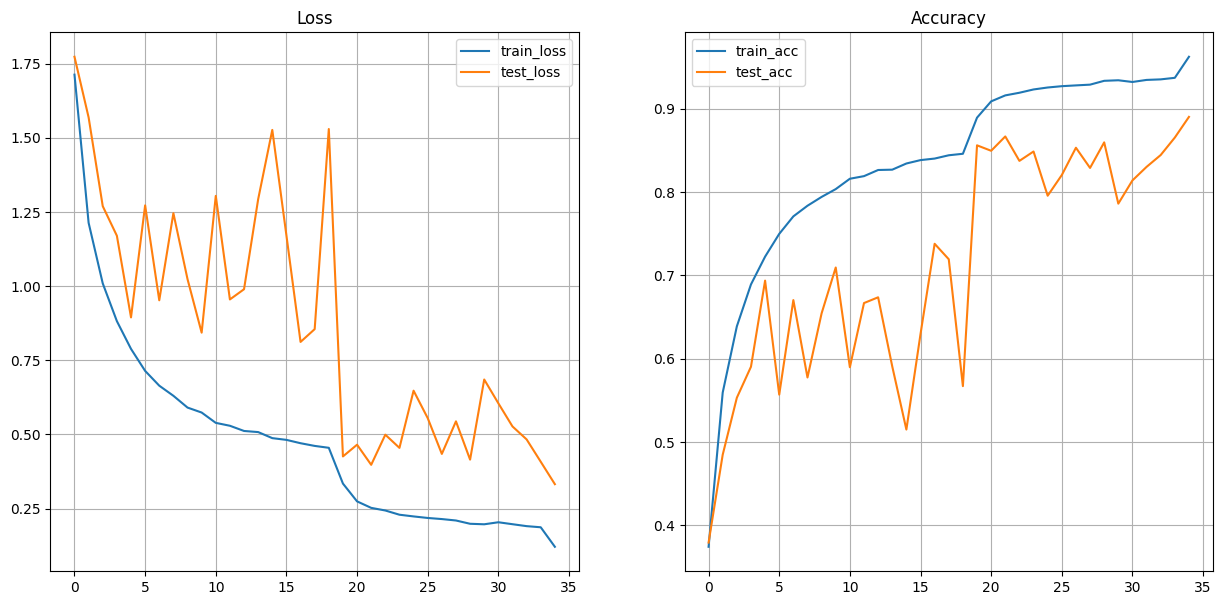

In [5]:
print("--- START: Baseline Training (Supervised) ---")

baseline_model = ResNet18(num_classes=10).to(device)
baseline_save_path = os.path.join(SAVE_DIR, 'resnet18_cifar10_baseline.pth')
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(baseline_model.parameters(), lr=0.001, weight_decay=35e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.3, patience=3, threshold=0.09)

baseline_results = train(
    model=baseline_model,
    train_dataloader=train_dataloader,
    test_dataloader=val_dataloader,
    optimizer=optimizer,
    scheduler=scheduler,
    grad_clip=0.0001,
    loss_fn=loss_fn,
    epochs=35,
    save_path=baseline_save_path
)

plot_loss_curves(baseline_results)

del baseline_model, optimizer, scheduler, baseline_results
torch.cuda.empty_cache()
gc.collect()

In [6]:
class ContrastiveTransformations:
    def __init__(self, base_transforms):
        self.base_transforms = base_transforms

    def __call__(self, x):
        return [self.base_transforms(x), self.base_transforms(x)]

simclr_transforms = transforms.Compose([
    transforms.RandomResizedCrop(size=32, scale=(0.2, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomApply([
        transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1)
    ], p=0.8),
    transforms.RandomGrayscale(p=0.2),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD)
])

train_contrastive_dataset = torchvision.datasets.CIFAR10(
    root='/content/', train=True, download=True,
    transform=ContrastiveTransformations(simclr_transforms)
)

contrastive_dataloader = DataLoader(
    train_contrastive_dataset,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    shuffle=True,
    drop_last=True
)

In [7]:
class SimCLR(nn.Module):
    def __init__(self, base_encoder, projection_dim=128):
        super().__init__()
        self.encoder = base_encoder
        num_features = self.encoder.fc.in_features
        self.encoder.fc = nn.Identity()
        self.projection_head = nn.Sequential(
            nn.Linear(num_features, num_features, bias=False),
            nn.ReLU(),
            nn.Linear(num_features, projection_dim, bias=False)
        )

    def forward(self, x):
        features = self.encoder(x)
        return self.projection_head(features)

class NTXentLoss(nn.Module):
    def __init__(self, temperature=0.5):
        super().__init__()
        self.temperature = temperature
        self.similarity_f = nn.CosineSimilarity(dim=2)
        self.criterion = nn.CrossEntropyLoss()

    def forward(self, z_i, z_j):
        batch_size = z_i.shape[0]
        z = torch.cat([z_i, z_j], dim=0)
        sim_matrix = self.similarity_f(z.unsqueeze(1), z.unsqueeze(0))

        sim_ij = torch.diag(sim_matrix, batch_size)
        sim_ji = torch.diag(sim_matrix, -batch_size)
        positive_samples = torch.cat([sim_ij, sim_ji], dim=0).reshape(2 * batch_size, 1)

        mask = (~torch.eye(2 * batch_size, 2 * batch_size, dtype=bool)).to(device)
        negative_samples = sim_matrix[mask].reshape(2 * batch_size, -1)

        logits = torch.cat([positive_samples, negative_samples], dim=1) / self.temperature
        labels = torch.zeros(2 * batch_size).to(device).long()

        return self.criterion(logits, labels)

In [8]:
print("--- START: SimCLR Pre-training ---")

PRETRAIN_EPOCHS = 300
PRETRAIN_LR = 1e-3
WEIGHT_DECAY = 1e-4

base_encoder = ResNet18(num_classes=10)
pretrain_model = SimCLR(base_encoder=base_encoder).to(device)

pretrain_loss_fn = NTXentLoss(temperature=0.5)
pretrain_optimizer = torch.optim.AdamW(pretrain_model.parameters(), lr=PRETRAIN_LR, weight_decay=WEIGHT_DECAY)


scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(pretrain_optimizer, T_max=PRETRAIN_EPOCHS, eta_min=1e-6)

encoder_save_path = os.path.join(SAVE_DIR, 'simclr_resnet18_encoder.pth')

for epoch in tqdm(range(PRETRAIN_EPOCHS)):
    pretrain_model.train()
    total_loss = 0

    for batch in contrastive_dataloader:
        images, _ = batch
        images_i, images_j = images[0].to(device), images[1].to(device)

        pretrain_optimizer.zero_grad()
        proj_i = pretrain_model(images_i
        proj_j = pretrain_model(images_j)

        loss = pretrain_loss_fn(proj_i, proj_j)
        loss.backward()
        pretrain_optimizer.step()

        total_loss += loss.item()

    scheduler.step()

    if (epoch+1) % 10 == 0:
        avg_loss = total_loss/len(contrastive_dataloader)
        lr_curr = scheduler.get_last_lr()[0]
        print(f"Epoch: {epoch+1:03d} | Loss: {avg_loss:.4f} | LR: {lr_curr:.6f}")

torch.save(pretrain_model.encoder.state_dict(), encoder_save_path)
print("SimCLR pre-training finished.")

del pretrain_model, pretrain_optimizer, contrastive_dataloader
torch.cuda.empty_cache()
gc.collect()

--- START: SimCLR Pre-training ---


  0%|          | 0/300 [00:00<?, ?it/s]

Epoch: 010 | Loss: 5.9181 | LR: 0.000997
Epoch: 020 | Loss: 5.8233 | LR: 0.000989
Epoch: 030 | Loss: 5.7800 | LR: 0.000976
Epoch: 040 | Loss: 5.7543 | LR: 0.000957
Epoch: 050 | Loss: 5.7386 | LR: 0.000933
Epoch: 060 | Loss: 5.7247 | LR: 0.000905
Epoch: 070 | Loss: 5.7136 | LR: 0.000872
Epoch: 080 | Loss: 5.7031 | LR: 0.000835
Epoch: 090 | Loss: 5.6898 | LR: 0.000794
Epoch: 100 | Loss: 5.6805 | LR: 0.000750
Epoch: 110 | Loss: 5.6745 | LR: 0.000704
Epoch: 120 | Loss: 5.6658 | LR: 0.000655
Epoch: 130 | Loss: 5.6588 | LR: 0.000604
Epoch: 140 | Loss: 5.6511 | LR: 0.000553
Epoch: 150 | Loss: 5.6467 | LR: 0.000501
Epoch: 160 | Loss: 5.6421 | LR: 0.000448
Epoch: 170 | Loss: 5.6341 | LR: 0.000397
Epoch: 180 | Loss: 5.6296 | LR: 0.000346
Epoch: 190 | Loss: 5.6264 | LR: 0.000297
Epoch: 200 | Loss: 5.6204 | LR: 0.000251
Epoch: 210 | Loss: 5.6170 | LR: 0.000207
Epoch: 220 | Loss: 5.6149 | LR: 0.000166
Epoch: 230 | Loss: 5.6119 | LR: 0.000129
Epoch: 240 | Loss: 5.6087 | LR: 0.000096
Epoch: 250 | Los

7417

In [9]:
finetune_full_dataset = torchvision.datasets.CIFAR10(
    root='/content/', train=True, download=True,
    transform=transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(CIFAR_MEAN, CIFAR_STD)
    ])
)

targets = np.array(finetune_full_dataset.targets)
finetune_indices = []
for i in range(10):
    class_indices = np.where(targets == i)[0]
    finetune_indices.extend(np.random.choice(class_indices, 50, replace=False))

finetune_dataset = torch.utils.data.Subset(finetune_full_dataset, finetune_indices)
finetune_dataloader = DataLoader(finetune_dataset, batch_size=64, num_workers=NUM_WORKERS, shuffle=True)

print(f"Fine-tuning na {len(finetune_dataset)} obrazach.")

Fine-tuning na 500 obrazach.


In [10]:
print("--- START: Fine-tuning (1% Data) ---")

finetune_model = ResNet18(num_classes=10).to(device)

finetune_model.fc = nn.Identity()

encoder_save_path = os.path.join(SAVE_DIR, 'simclr_resnet18_encoder.pth')
finetune_model.load_state_dict(torch.load(encoder_save_path))

for param in finetune_model.parameters():
    param.requires_grad = False

finetune_model.fc = nn.Linear(512, 10).to(device)

print("Trenowane parametry:")
for name, param in finetune_model.named_parameters():
    if param.requires_grad:
        print(f" -> {name}")

optimizer = torch.optim.Adam(finetune_model.fc.parameters(), lr=1e-3)
finetune_save_path = os.path.join(SAVE_DIR, 'resnet18_finetuned_1_percent.pth')

finetune_results = train(
    model=finetune_model,
    train_dataloader=finetune_dataloader,
    test_dataloader=val_dataloader,
    optimizer=optimizer,
    scheduler=None,
    epochs=20,
    save_path=finetune_save_path
)

--- START: Fine-tuning (1% Data) ---
Trenowane parametry:
 -> fc.weight
 -> fc.bias


  0%|          | 0/20 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 2.1156 | train_acc: 0.2716 | test_loss: 1.7301 | test_acc: 0.5274
 New best model saved. Val Loss: 1.7301
Epoch: 2 | train_loss: 1.5399 | train_acc: 0.6258 | test_loss: 1.3616 | test_acc: 0.7011
 New best model saved. Val Loss: 1.3616
Epoch: 3 | train_loss: 1.2146 | train_acc: 0.7891 | test_loss: 1.1437 | test_acc: 0.7688
 New best model saved. Val Loss: 1.1437
Epoch: 4 | train_loss: 1.0239 | train_acc: 0.8128 | test_loss: 1.0151 | test_acc: 0.7852
 New best model saved. Val Loss: 1.0151
Epoch: 5 | train_loss: 0.8791 | train_acc: 0.8410 | test_loss: 0.9330 | test_acc: 0.7901
 New best model saved. Val Loss: 0.9330
Epoch: 6 | train_loss: 0.8044 | train_acc: 0.8436 | test_loss: 0.8887 | test_acc: 0.7876
 New best model saved. Val Loss: 0.8887
Epoch: 7 | train_loss: 0.7565 | train_acc: 0.8286 | test_loss: 0.8536 | test_acc: 0.7899
 New best model saved. Val Loss: 0.8536
Epoch: 8 | train_loss: 0.7103 | train_acc: 0.8430 | test_loss: 0.8226 | test_acc: 0.7901
 New bes

In [11]:
print("\n--- FINAL RESULTS ---")

loss_fn = nn.CrossEntropyLoss()

finetune_model.load_state_dict(torch.load(finetune_save_path))
_, acc_simclr = test_step(finetune_model, test_dataloader, loss_fn)
print(f"SimCLR (Trained on 1% Data): {acc_simclr*100:.2f}% Accuracy")

baseline_model = ResNet18(num_classes=10).to(device)
baseline_save_path = os.path.join(SAVE_DIR, 'resnet18_cifar10_baseline.pth')
baseline_model.load_state_dict(torch.load(baseline_save_path))

_, acc_baseline = test_step(baseline_model, test_dataloader, loss_fn)
print(f"Baseline (Trained on 100% Data): {acc_baseline*100:.2f}% Accuracy")


--- FINAL RESULTS ---
SimCLR (Trained on 1% Data): 80.29% Accuracy
Baseline (Trained on 100% Data): 89.25% Accuracy
